# RQ1 — Structural Nature of Agent-Authored Merge Conflicts

> *In merge commits that occur inside agent-authored PRs, what are the
> distributions of (i) the number of conflicting chunks per failed merge,
> (ii) the size in lines of code of `v1`, (iii) the size in lines of
> code of `v2`, and (iv) the size in lines of code of the resolution?*
> — PLAN.md §3 (RQ1)

This notebook reproduces the four structural distributions of Ghiotto
et al. (TSE 2020, figures A1, A2) over the agent universe, plus the new
`resolution_loc` metric (PLAN.md §5.5). Every figure is emitted both
globally and stratified along the three cross-cutting axes: **agent**,
**language** (top-N), and **pr_task_type**.

All figures are saved to `analysis/figures/` as `.pdf` + `.png`.


In [1]:
# Ensure the project root is on sys.path so ``analysis.common`` imports
# cleanly whether the kernel was launched from the repo root or from
# inside analysis/.
import sys
from pathlib import Path

_here = Path.cwd()
for candidate in [_here, *_here.parents]:
    if (candidate / "analysis" / "common.py").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from analysis.common import (
    load_tables,
    build_chunk_frame, build_merge_frame, build_pr_frame,
    setup_style, save_fig,
    stratify, stratum_order,
    descriptive_table, strategy_distribution,
    STRATEGY_ORDER, STRATEGY_PALETTE,
    RESOLVER_ORDER, RESOLVER_PALETTE,
    PR_OUTCOME_ORDER, PR_OUTCOME_PALETTE,
    TOP_N_LANGUAGES,
)

setup_style()
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)


## 1. Load pipeline outputs

In [2]:
tables = load_tables()
print("Universe rows (pr_id, sha):", len(tables.universe))
print("Internal merges:          ", len(tables.internal_merges))
print("Classified chunks:        ", len(tables.classified_chunks))
print("Resolved chunks:          ", len(tables.resolved_chunks))
print("Extraction errors:        ", len(tables.extraction_errors))


Universe rows (pr_id, sha): 7347676
Internal merges:           40017
Classified chunks:         98322
Resolved chunks:           98322
Extraction errors:         2814495


## 2. Build analysis frames

In [3]:
chunks  = build_chunk_frame(tables)
merges  = build_merge_frame(tables)

# Only failed merges carry chunk-level distributions.
failed_merges = merges[merges["has_conflict"]].copy()

print(f"Chunks (classified):     {len(chunks):>10,}")
print(f"Internal merges:         {len(merges):>10,}")
print(f"Internal merges w/ conflict: {len(failed_merges):>6,}  "
      f"({len(failed_merges)/max(len(merges),1):.1%})")
chunks.head()


Chunks (classified):         98,322
Internal merges:             40,017
Internal merges w/ conflict: 10,232  (25.6%)


,repo_full_name,pr_id,merge_sha,file_path,chunk_index,v1,base,v2,v1_loc,v2_loc,base_loc,resolution,localized_ok,resolution_loc,strategy,strategy_raw,resolver_type,full_name,agent,language,pr_task_type,state,merged_at,language_top
0,0x80/isolate-package,3226855748,7f4cb65dee3fcaf390fbd514ebf80a672715e63e,package.json,0,"""version"": ""1.24.0-1"",","""version"": ""1.24.0-0"",","""version"": ""1.24.0"",",1,1,1,"""version"": ""1.24.0-1"",\n",True,1,V1,V1,human,0x80/isolate-package,Cursor,TypeScript,fix,open,None,TypeScript
1,0xSMW/grok3-pro,3147262825,61c349fb7f49b0cbd670e703a2dcb39e3fa87e23,eval-harness.ts,0,const attempts: any[] = []\n for (let i...,const { text: answer } = await generateTex...,const { text: answer } = await generateTex...,30,17,3,\n const attempts: any[] = []\n for (let...,True,30,V1,V1,human,0xSMW/grok3-pro,OpenAI_Codex,TypeScript,None,open,None,TypeScript
2,0xSMW/grok3-pro,3147262825,62e8956c36b461c30f3457d978db1db5ee5441ae,README.md,0,Defaults are read from `config.yaml` if it exi...,Run without flags to launch an interactive men...,Run without flags to launch an interactive men...,1,2,1,\nDefaults are read from `config.yaml` if it e...,True,3,CC,ConcatV1V2,human,0xSMW/grok3-pro,OpenAI_Codex,TypeScript,None,open,None,TypeScript
3,0xSMW/grok3-pro,3147262825,62e8956c36b461c30f3457d978db1db5ee5441ae,cli.tsx,0,\n if (existsSync('config.yaml')) {\n try ...,,let bestOf = 1,14,1,0,\n\n if (existsSync('config.yaml')) {\n tr...,True,15,CC,ConcatV1V2,human,0xSMW/grok3-pro,OpenAI_Codex,TypeScript,None,open,None,TypeScript
4,0xobelisk/merak,3071081395,04525d694dee6c1e6db733e96eda3a61881db8e9,README.md,0,# sov-front-end-template\n\n## Running Tests\n...,# sov-front-end-template,A GitHub Actions workflow installs dependencie...,8,1,1,\n# sov-front-end-template\n\n## Running Tests...,True,9,CC,ConcatV1V2,human,0xobelisk/merak,OpenAI_Codex,TypeScript,None,closed,2025-05-17T21:39:59Z,TypeScript


In [4]:
chunks[chunks['v1_loc']>100000]

,repo_full_name,pr_id,merge_sha,file_path,chunk_index,v1,base,v2,v1_loc,v2_loc,base_loc,resolution,localized_ok,resolution_loc,strategy,strategy_raw,resolver_type,full_name,agent,language,pr_task_type,state,merged_at,language_top
11183,Bryan-Roe-ai/semantic-kernel,3267487474,0dd332bc445dee135f3913a433e00f585400af74,semantic-kernel,1,diff --git a/.devcontainer/devcontainer.json b...,diff --git a/.github/workflows/dotnet-build-an...,- <VersionPrefix>1.16.2</VersionPrefix>\n-,199765,2,221,None,False,0,Imprecise,Imprecise,human,Bryan-Roe-ai/semantic-kernel,OpenAI_Codex,C#,None,closed,2025-07-27T22:36:22Z,C#


## 3. Descriptive statistics (Ghiotto-style summary)

In [5]:
summary_rows = []
if not failed_merges.empty:
    summary_rows.append(
        descriptive_table(failed_merges["n_chunks"]).rename("chunks_per_merge"))
for col in ("v1_loc", "v2_loc", "resolution_loc"):
    if col in chunks.columns:
        summary_rows.append(descriptive_table(chunks[col]).rename(col))
summary_df = pd.concat(summary_rows, axis=1) if summary_rows else pd.DataFrame()
summary_df.round(2)


,chunks_per_merge,v1_loc,v2_loc,resolution_loc
n,10232.00,98322.00,98322.00,98322.00
mean,9.61,39.88,18.77,70.99
std,108.19,992.67,442.98,1070.96
min,1.00,0.00,0.00,0.00
p25,1.00,1.00,1.00,0.00
median,2.00,3.00,2.00,1.00
p75,4.00,14.00,6.00,6.00
p90,12.00,38.00,17.00,34.00
p95,24.00,72.00,33.00,132.00
p99,122.00,280.00,130.00,1525.79


## 4. Figure 1 — Chunks per failed merge (global)

Histogram with log-scaled y axis plus an empirical CDF overlay. This
corresponds to Ghiotto et al.'s A1.


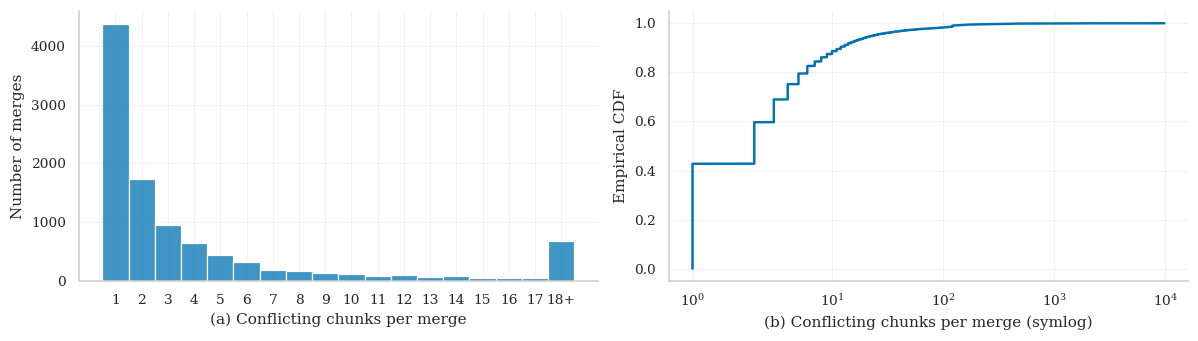

In [6]:
failed_merges["n_chunks_capped"] = failed_merges["n_chunks"].clip(upper=18)
if not failed_merges.empty:
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))

    sns.histplot(
        failed_merges["n_chunks_capped"],
        bins=np.arange(0.5, 19.5, 1),
        ax=axes[0],
        color=STRATEGY_PALETTE["V1"],
    )
    xticks = list(range(1, 19)) 
    xticklabels = [str(i) for i in xticks]
    xticklabels[-1] = "18+"

    axes[0].set_xticks(xticks)
    axes[0].set_xticklabels(xticklabels)
    # axes[0].set_yscale("log")
    axes[0].set_xlabel("(a) Conflicting chunks per merge")
    axes[0].set_ylabel("Number of merges")

    sorted_n = np.sort(failed_merges["n_chunks"].values)
    cdf = np.arange(1, len(sorted_n) + 1) / len(sorted_n)
    axes[1].plot(sorted_n, cdf, color=STRATEGY_PALETTE["V1"], lw=1.6)
    axes[1].set_xscale("symlog")
    axes[1].set_xlabel("(b) Conflicting chunks per merge (symlog)")
    axes[1].set_ylabel("Empirical CDF")

    save_fig(fig, "rq1_chunks_per_merge_global")
    plt.show()
else:
    print("No failed merges available yet -- run the pipeline first.")


## 5. Figure 2 — Chunk-level LOC distributions (global)

One panel per metric (`v1_loc`, `v2_loc`, `resolution_loc`). Log-scaled
y axis so the long tail remains visible. Ghiotto et al. A2 only reports
`v1` / `v2`; our `resolution_loc` adds the new third distribution.


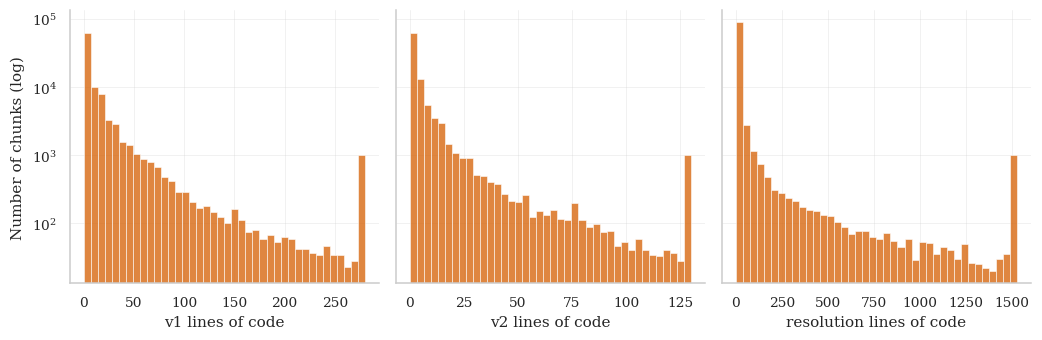

In [7]:
metrics = [("v1_loc", "v1 lines of code"),
           ("v2_loc", "v2 lines of code"),
           ("resolution_loc", "resolution lines of code")]
metrics = [(c, lab) for c, lab in metrics if c in chunks.columns]

if chunks.empty or not metrics:
    print("Chunk-level data missing -- run the pipeline first.")
else:
    fig, axes = plt.subplots(1, len(metrics), figsize=(3.2 * len(metrics), 3.2), sharey=True)
    if len(metrics) == 1:
        axes = [axes]
    for ax, (col, label) in zip(axes, metrics):
        data = chunks[col].clip(upper=chunks[col].quantile(0.99))
        sns.histplot(data, bins=40, ax=ax, color=STRATEGY_PALETTE["V2"])
        ax.set_yscale("log")
        ax.set_xlabel(label)
    axes[0].set_ylabel("Number of chunks (log)")
    save_fig(fig, "rq1_loc_distributions_global")
    plt.show()


## 6. Figure 3 — Chunks per merge by agent

Per-agent boxplot on the log scale. Reveals whether, say, Copilot
produces merges with systematically more or fewer conflict chunks
than Codex.


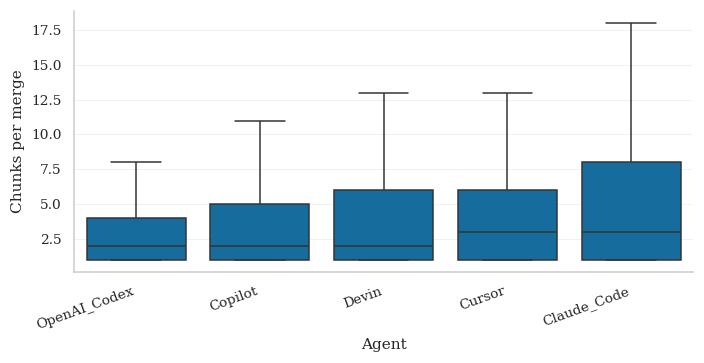

In [8]:
if not failed_merges.empty and "agent" in failed_merges.columns:
    agent_order = stratum_order(failed_merges, "agent")
    fig, ax = plt.subplots(figsize=(max(5, 0.9 * len(agent_order) + 2), 3.4))
    sns.boxplot(
        data=failed_merges, x="agent", y="n_chunks",
        order=agent_order, showfliers=False, ax=ax, color=STRATEGY_PALETTE["V1"],
    )
    # ax.set_yscale("symlog")
    ax.set_xlabel("Agent")
    ax.set_ylabel("Chunks per merge")
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
    save_fig(fig, "rq1_chunks_per_merge_by_agent")
    plt.show()
else:
    print("Need failed merges with an 'agent' column.")


## 7. Figure 4 — Chunk LOC by agent (faceted)

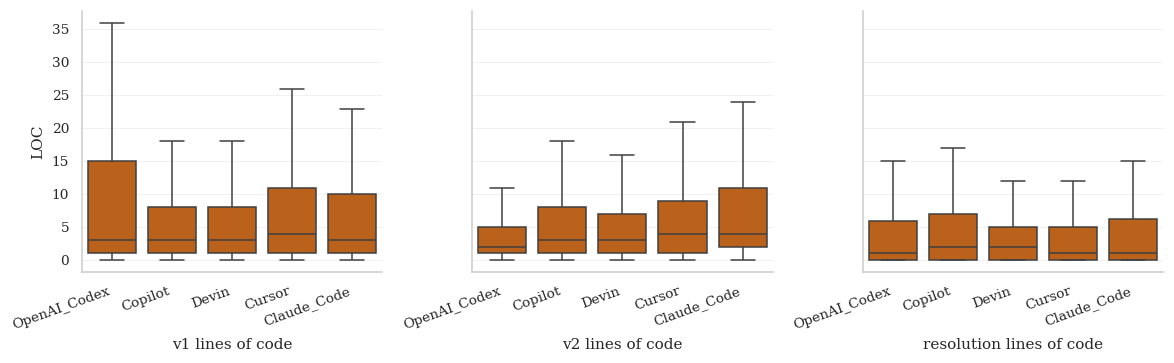

In [9]:
if not chunks.empty and "agent" in chunks.columns and metrics:
    long_df = chunks.melt(
        id_vars=["agent"],
        value_vars=[c for c, _ in metrics],
        var_name="metric", value_name="loc",
    ).dropna()

    agent_order = stratum_order(chunks, "agent")
    fig, axes = plt.subplots(1, len(metrics), figsize=(3.6 * len(metrics), 3.4), sharey=True)
    if len(metrics) == 1:
        axes = [axes]
    for ax, (col, label) in zip(axes, metrics):
        d = long_df[long_df["metric"] == col]
        sns.boxplot(data=d, x="agent", y="loc", order=agent_order,
                    showfliers=False, ax=ax, color=STRATEGY_PALETTE["V2"])
        # ax.set_yscale("symlog")
        ax.set_xlabel(label)
        plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
    axes[0].set_ylabel("LOC")
    save_fig(fig, "rq1_loc_by_agent")
    plt.show()


## 8. Figure 5 — Chunks per merge by language (top-N)

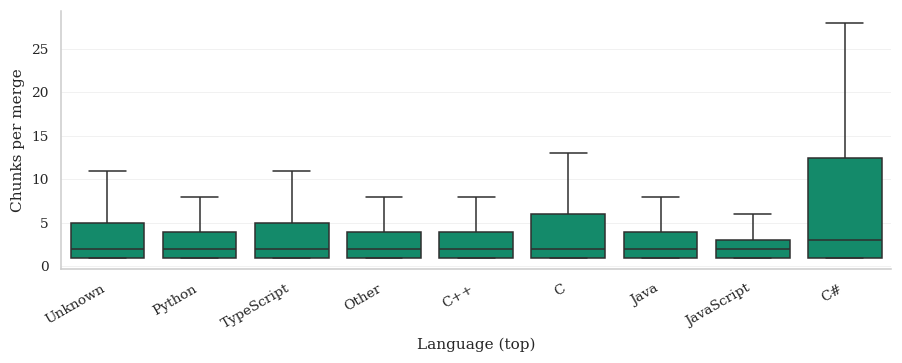

In [10]:
if not failed_merges.empty and "language_top" in failed_merges.columns:
    lang_order = stratum_order(failed_merges, "language")
    fig, ax = plt.subplots(figsize=(max(5, 0.7 * len(lang_order) + 2), 3.4))
    sns.boxplot(
        data=failed_merges, x="language_top", y="n_chunks",
        order=lang_order, showfliers=False, ax=ax, color=STRATEGY_PALETTE["CC"],
    )
    # ax.set_yscale("symlog")
    ax.set_xlabel("Language (top)")
    ax.set_ylabel("Chunks per merge")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    save_fig(fig, "rq1_chunks_per_merge_by_language")
    plt.show()


## 9. Figure 6 — Chunks per merge by PR task type

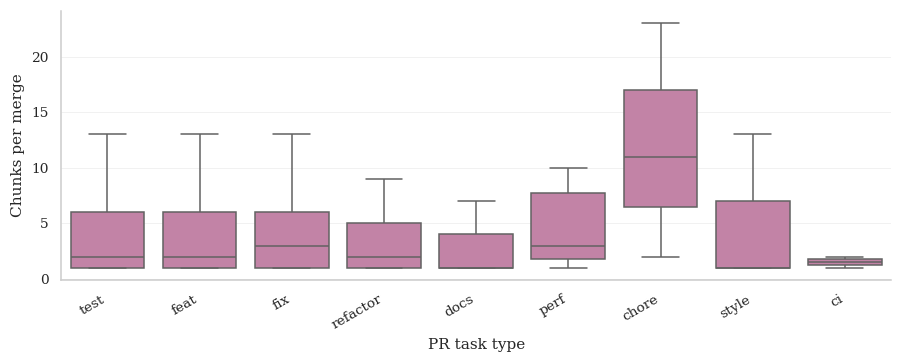

In [11]:
if not failed_merges.empty and "pr_task_type" in failed_merges.columns:
    subset = failed_merges.dropna(subset=["pr_task_type"]).copy()
    if subset.empty:
        print("pr_task_type is only populated under --pop-only (AIDev's enriched tier).")
    else:
        task_order = stratum_order(subset, "pr_task_type")
        fig, ax = plt.subplots(figsize=(max(5, 0.7 * len(task_order) + 2), 3.4))
        sns.boxplot(
            data=subset, x="pr_task_type", y="n_chunks",
            order=task_order, showfliers=False, ax=ax, color=STRATEGY_PALETTE["CB"],
        )
        # ax.set_yscale("symlog")
        ax.set_xlabel("PR task type")
        ax.set_ylabel("Chunks per merge")
        plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
        save_fig(fig, "rq1_chunks_per_merge_by_task_type")
        plt.show()


## 10. Per-stratum descriptive tables

In [12]:
def stratum_descriptive(df, group_col, numeric_col):
    if df.empty or group_col not in df.columns:
        return pd.DataFrame()
    return (
        df.groupby(group_col)[numeric_col]
          .apply(descriptive_table)
          .unstack()
          .round(2)
          .sort_values("n", ascending=False)
    )

tables_out = {}
if not failed_merges.empty:
    tables_out["chunks_per_merge_by_agent"] = stratum_descriptive(
        failed_merges, "agent", "n_chunks")
    tables_out["chunks_per_merge_by_language"] = stratum_descriptive(
        failed_merges, "language_top", "n_chunks")
for col in ("v1_loc", "v2_loc", "resolution_loc"):
    if col in chunks.columns:
        tables_out[f"{col}_by_agent"] = stratum_descriptive(
            chunks, "agent", col)

for name, t in tables_out.items():
    print(f"\n=== {name} ===")
    print(t.to_string() if not t.empty else "(no rows)")



=== chunks_per_merge_by_agent ===
                   n   mean     std  min  p25  median  p75   p90    p95     p99     max
agent                                                                                  
OpenAI_Codex  8105.0   9.57  119.71  1.0  1.0     2.0  4.0  11.0  23.00  122.00  9791.0
Copilot       1170.0  10.38   46.88  1.0  1.0     2.0  5.0  14.0  27.00  188.03   876.0
Devin          546.0   8.98   37.54  1.0  1.0     2.0  6.0  14.0  22.00  107.50   684.0
Cursor         311.0   8.52   27.98  1.0  1.0     3.0  6.0  17.0  24.00   88.30   331.0
Claude_Code    100.0  10.28   20.12  1.0  1.0     3.0  8.0  26.1  45.15   98.33   131.0

=== chunks_per_merge_by_language ===
                   n   mean     std  min  p25  median   p75   p90     p95     p99     max
language_top                                                                             
Unknown       1840.0   8.10   27.12  1.0  1.0     2.0   5.0  13.0   28.05  110.22   684.0
Python        1630.0   4.41   12.32  1.0 

---
### Outputs summary

This notebook writes (one PDF + one PNG each) to `analysis/figures/`:

| File stem                              | Paper role |
|----------------------------------------|------------|
| `rq1_chunks_per_merge_global`          | Figure: overall A1 replication |
| `rq1_loc_distributions_global`         | Figure: overall A2 replication + resolution_loc |
| `rq1_chunks_per_merge_by_agent`        | Stratified by agent |
| `rq1_loc_by_agent`                     | Stratified by agent (LOC panels) |
| `rq1_chunks_per_merge_by_language`     | Stratified by language (top-N) |
| `rq1_chunks_per_merge_by_task_type`    | Stratified by `pr_task_type` (AIDev-pop only) |

Numerical tables are printed above for inclusion in the paper.
